# Dynamic Multimodal Facial Expression Recognition

## Intermediate Fusion

This notebook trains and evaluates intermediate-fusion models for dynamic facial expression recognition using synchronized image and FEA sequences from EmoHeVRDB.

Each multimodal sample consists of:

- one 30-frame image sequence from either the Central or Side view
- one synchronized sequence of 30 FEA vectors with 63 features each
- one expression label

The pretrained dynamic Image and FEA baseline models are reused as frozen feature extractors. Model configuration and hyperparameter selection are performed on the validation set. The test set is reserved for the final evaluation of the selected model.

In [1]:
name_of_this_notebook = 'intermediate_fusion_cross_attention.ipynb'


In [2]:
import os

environment_variables = [
    "PYTHONUNBUFFERED",
    "TF_CPP_MIN_LOG_LEVEL",
    "TF_FORCE_GPU_ALLOW_GROWTH",
    "TF_GPU_ALLOCATOR",
    "PYTHONHASHSEED"
]

for variable in environment_variables:
    print(f"{variable}: {os.getenv(variable)}")
    

PYTHONUNBUFFERED: None
TF_CPP_MIN_LOG_LEVEL: 2
TF_FORCE_GPU_ALLOW_GROWTH: true
TF_GPU_ALLOCATOR: cuda_malloc_async
PYTHONHASHSEED: None


In [3]:
import re
import ipykernel.iostream

TF_LOG_FILTER_PATTERNS = [
    r'ptx\d+.*is not a recognized feature for this target',
    r'is not a recognized feature for this target \(ignoring feature\)',
    r'\(ignoring feature\)',
    r'successful NUMA node read from SysFS had negative value \(-1\)',
    r'gpu_timer\.cc:114\] Skipping the delay kernel, measurement accuracy will be reduced',
]

KERAS_PROGRESS_PATTERNS = [
    r'ms/step',
    r's/step',
    r'ETA:',
    r'\d+/\d+ \[',   # 12/64 [===>...]
]

_original_write = ipykernel.iostream.OutStream.write

def _filtered_write(self, msg, *args, **kwargs):
    text = str(msg)

    if any(re.search(p, text) for p in KERAS_PROGRESS_PATTERNS):
        _original_write(self, text, *args, **kwargs)
        return

    buf = getattr(self, '_tf_log_filter_buf', '')
    buf += text

    if '\n' not in buf:
        setattr(self, '_tf_log_filter_buf', buf)
        return

    lines = buf.splitlines(keepends=True)
    if not buf.endswith('\n'):
        incomplete = lines.pop()
    else:
        incomplete = ''

    for line in lines:
        if any(re.search(p, line) for p in TF_LOG_FILTER_PATTERNS):
            continue
        _original_write(self, line, *args, **kwargs)

    setattr(self, '_tf_log_filter_buf', incomplete)

ipykernel.iostream.OutStream.write = _filtered_write

print('Notebook log filter installed (targeted, keeps Keras steps).')


Notebook log filter installed (targeted, keeps Keras steps).


In [4]:
import keras

keras.mixed_precision.set_global_policy('mixed_float16')
print("Mixed precision policy:", keras.mixed_precision.global_policy())


2026-09-16 21:50:23.562187: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-16 21:50:23.570599: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-16 21:50:23.573078: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Mixed precision policy: <DTypePolicy "mixed_float16">


In [5]:
from pathlib import Path

import json
import random

import numpy as np
import pandas as pd
import tensorflow as tf


In [6]:
SEED = 13

random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)
tf.random.set_seed(SEED)


In [7]:
print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {keras.__version__}")

gpus = tf.config.list_physical_devices("GPU")

if not gpus:
    raise RuntimeError("No GPU detected.")

print(f"GPUs detected: {len(gpus)}")

for gpu in gpus:
    device_details = tf.config.experimental.get_device_details(gpu)
    print(f"Physical device: {gpu.name}")
    print(f"Device name: {device_details.get('device_name')}")
    print(f"Compute capability: {device_details.get('compute_capability')}")

print("\nTensorFlow build information:")
print(json.dumps(tf.sysconfig.get_build_info(), indent=2))

TensorFlow: 2.17.0
Keras: 3.12.0
GPUs detected: 1
Physical device: /physical_device:GPU:0
Device name: NVIDIA GeForce RTX 5090
Compute capability: (12, 0)

TensorFlow build information:
{
  "cpu_compiler": "/opt/rh/gcc-toolset-11/root/usr/bin/gcc",
  "cuda_compute_capabilities": [
    "sm_100",
    "sm_120",
    "sm_75",
    "sm_80",
    "sm_86",
    "compute_90"
  ],
  "cuda_version": "12.8",
  "cudnn_version": "9",
  "is_cuda_build": true,
  "is_rocm_build": false,
  "is_tensorrt_build": true
}


In [8]:
SEQUENCE_LENGTH = 30
IMAGE_SIZE = (224, 224, 3)
NUM_FEA_FEATURES = 63
NUM_CLASSES = 7

BATCH_SIZE = 32
LR = 5e-4

In [9]:
experiment_name = f"{Path(name_of_this_notebook).stem}-seed-{SEED}"

print("Experiment:", experiment_name)

Experiment: intermediate_fusion_cross_attention-seed-13


## Prepare Data

The multimodal datasets are constructed by matching each dynamic image sequence from EmoHeVRDB-DI with the synchronized FEA sequence from EmoHeVRDB-DFEA belonging to the same reenactment.

Because each reenactment has one FEA sequence but two image sequences, one Central and one Side view, each FEA sequence contributes to two multimodal samples.

In [10]:
dataset_path = Path("/workspace/datasets")

emotion_to_id = {
    "Anger": 0,
    "Disgust": 1,
    "Fear": 2,
    "Happiness": 3,
    "Neutral": 4,
    "Sadness": 5,
    "Surprise": 6
}

id_to_emotion = {v: k for k, v in emotion_to_id.items()}

assert dataset_path.exists(), f"Dataset directory not found: {dataset_path}"
assert len(emotion_to_id) == NUM_CLASSES

### Prepare FEA Sequences

EmoHeVRDB-DFEA stores one row per time step. Each sequence contains exactly 30 temporally ordered observations, each comprising a timestamp, 63 FEA values, and the inherited expression label.

The following cells convert the tabular representation into one 30 × 63 array per reenactment and validate the expected split sizes.

In [11]:
fea_dataset_path = dataset_path / "emoji-hero-vr-db-dfea-as-csv"

fea_train_df = pd.read_csv(fea_dataset_path / "training_set.csv")
fea_val_df = pd.read_csv(fea_dataset_path / "validation_set.csv")
fea_test_df = pd.read_csv(fea_dataset_path / "test_set.csv")

print(f"Training rows:   {len(fea_train_df):>5}")
print(f"Validation rows: {len(fea_val_df):>5}")
print(f"Test rows:       {len(fea_test_df):>5}")

metadata_columns = {"sequence_id", "timestamp", "Label"}
fea_feature_columns = [column for column in fea_train_df.columns if column not in metadata_columns]

assert len(fea_feature_columns) == NUM_FEA_FEATURES
assert list(fea_train_df.columns) == list(fea_val_df.columns) == list(fea_test_df.columns)

assert fea_train_df["sequence_id"].nunique() == 964
assert fea_val_df["sequence_id"].nunique() == 385
assert fea_test_df["sequence_id"].nunique() == 378

assert len(fea_train_df) == 964 * SEQUENCE_LENGTH
assert len(fea_val_df) == 385 * SEQUENCE_LENGTH
assert len(fea_test_df) == 378 * SEQUENCE_LENGTH

print(f"FEA features: {len(fea_feature_columns)}")

Training rows:   28920
Validation rows: 11550
Test rows:       11340
FEA features: 63


In [12]:
def prepare_data(df: pd.DataFrame) -> dict[str, tuple[np.ndarray, np.ndarray, int]]:
    sequences = {}

    for sequence_id, group in df.groupby("sequence_id", sort=True):
        group = group.sort_values("timestamp")

        assert len(group) == SEQUENCE_LENGTH, f"{sequence_id}: expected {SEQUENCE_LENGTH} observations, found {len(group)}"
        assert group["timestamp"].is_unique, f"{sequence_id}: duplicate timestamps"
        assert group["Label"].nunique() == 1, f"{sequence_id}: inconsistent labels"

        timestamps = group["timestamp"].to_numpy(dtype=np.int64)
        features = group[fea_feature_columns].to_numpy(dtype=np.float32)
        label = int(group["Label"].iloc[0])

        assert features.shape == (SEQUENCE_LENGTH, NUM_FEA_FEATURES)
        assert np.isfinite(features).all()

        sequences[sequence_id] = (timestamps, features, label)

    return sequences


fea_sequences_train = prepare_data(fea_train_df)
fea_sequences_val = prepare_data(fea_val_df)
fea_sequences_test = prepare_data(fea_test_df)

print(f"Training FEA sequences:   {len(fea_sequences_train)}")
print(f"Validation FEA sequences: {len(fea_sequences_val)}")
print(f"Test FEA sequences:       {len(fea_sequences_test)}")

Training FEA sequences:   964
Validation FEA sequences: 385
Test FEA sequences:       378


### Combine FEA Sequences with Image Sequences

Each FEA sequence is matched with its corresponding Central- and Side-view image sequences using the reenactment identifier encoded in the image-sequence directory name.

For every matched multimodal sample, we require:

- exactly 30 image frames
- exactly 30 FEA vectors
- identical expression labels
- identical frame and FEA timestamps

Image sequences without corresponding FEA data are skipped because the multimodal benchmark is defined on the intersection of EmoHeVRDB-DI and EmoHeVRDB-DFEA.

In [13]:
image_dataset_path = dataset_path / "emoji-hero-vr-db-di"

image_train_set_path = image_dataset_path / "training_set"
image_val_set_path = image_dataset_path / "validation_set"
image_test_set_path = image_dataset_path / "test_set"

for path in [image_train_set_path, image_val_set_path, image_test_set_path]:
    assert path.exists(), f"Dataset split not found: {path}"

In [14]:
def load_image_sequence_paths(
    image_dataset_path: Path,
    fea_sequences_d: dict[str, tuple[np.ndarray, np.ndarray, int]]
) -> tuple[list[np.ndarray], list[list[str]], list[int]]:
    
    print(f"Loading multimodal samples from: {image_dataset_path}")

    fea_sequences = []
    img_sequence_paths = []
    labels = []

    missing_fea_count = 0

    for class_dir in sorted(image_dataset_path.iterdir()):
        if not class_dir.is_dir():
            continue

        image_label = emotion_to_id[class_dir.name]

        for sequence_dir in sorted(class_dir.iterdir()):
            if not sequence_dir.is_dir():
                continue

            sequence_id, camera_index = sequence_dir.name.rsplit("-", 1)

            assert camera_index in {"0", "1"}, f"Unexpected camera index: {sequence_dir.name}"

            matching_fea_sequence = fea_sequences_d.get(sequence_id)

            if matching_fea_sequence is None:
                missing_fea_count += 1
                continue

            fea_timestamps, fea_features, fea_label = matching_fea_sequence

            image_paths = sorted(sequence_dir.glob("*.jpg"), key=lambda path: int(path.name.split("-")[0]))

            assert len(image_paths) == SEQUENCE_LENGTH, (
                f"{sequence_dir.name}: expected {SEQUENCE_LENGTH} image frames, found {len(image_paths)}"
            )

            image_timestamps = np.array(
                [int(path.name.split("-")[0]) for path in image_paths],
                dtype=np.int64
            )

            assert len(fea_timestamps) == SEQUENCE_LENGTH
            assert fea_features.shape == (SEQUENCE_LENGTH, NUM_FEA_FEATURES)
            assert image_label == fea_label, f"{sequence_dir.name}: image and FEA labels differ"
            assert np.array_equal(image_timestamps, fea_timestamps), f"{sequence_dir.name}: image and FEA timestamps differ"

            fea_sequences.append(fea_features)
            img_sequence_paths.append([str(path) for path in image_paths])
            labels.append(image_label)

    print(f"Matched multimodal samples: {len(labels)}")
    print(f"Image sequences without matching FEA data: {missing_fea_count}")

    return fea_sequences, img_sequence_paths, labels

In [15]:
train_fea_sequences, train_img_sequences, train_labels = load_image_sequence_paths(
    image_train_set_path,
    fea_sequences_train
)

val_fea_sequences, val_img_sequences, val_labels = load_image_sequence_paths(
    image_val_set_path,
    fea_sequences_val
)

test_fea_sequences, test_img_sequences, test_labels = load_image_sequence_paths(
    image_test_set_path,
    fea_sequences_test
)


expected_split_sizes = {
    "training": 1928,
    "validation": 770,
    "test": 756
}

assert len(train_labels) == expected_split_sizes["training"]
assert len(val_labels) == expected_split_sizes["validation"]
assert len(test_labels) == expected_split_sizes["test"]

assert len(train_fea_sequences) == len(train_img_sequences) == len(train_labels)
assert len(val_fea_sequences) == len(val_img_sequences) == len(val_labels)
assert len(test_fea_sequences) == len(test_img_sequences) == len(test_labels)

print("\nFinal multimodal split sizes:")
print(f"Training:   {len(train_labels)}")
print(f"Validation: {len(val_labels)}")
print(f"Test:       {len(test_labels)}")

Loading multimodal samples from: /workspace/datasets/emoji-hero-vr-db-di/training_set
Matched multimodal samples: 1928
Image sequences without matching FEA data: 102
Loading multimodal samples from: /workspace/datasets/emoji-hero-vr-db-di/validation_set
Matched multimodal samples: 770
Image sequences without matching FEA data: 0
Loading multimodal samples from: /workspace/datasets/emoji-hero-vr-db-di/test_set
Matched multimodal samples: 756
Image sequences without matching FEA data: 0

Final multimodal split sizes:
Training:   1928
Validation: 770
Test:       756


### Prepare TensorFlow Datasets

Images are loaded lazily from disk when batches are requested. FEA sequences are kept as 30 × 63 floating-point arrays.

Training samples are shuffled reproducibly. Validation and test samples retain a deterministic order.

No image sequences are cached in memory because each sample contains 30 RGB frames and the complete multimodal dataset is comparatively large.

In [16]:
def parse_image(filename: tf.Tensor) -> tf.Tensor:
    image_bytes = tf.io.read_file(filename)
    image = tf.io.decode_jpeg(image_bytes, channels=IMAGE_SIZE[2])
    image = tf.ensure_shape(image, IMAGE_SIZE)
    return image

def load_sequence(images_paths: tf.Tensor) -> tf.Tensor:
    images = tf.map_fn(parse_image, images_paths, fn_output_signature=tf.TensorSpec(shape=IMAGE_SIZE, dtype=tf.uint8))
    return tf.ensure_shape(images, (SEQUENCE_LENGTH, *IMAGE_SIZE))


def load_multimodal_sample(feas: tf.Tensor, image_paths: tf.Tensor, label: tf.Tensor):
    feas = tf.ensure_shape(feas, (SEQUENCE_LENGTH, NUM_FEA_FEATURES))
    images = load_sequence(image_paths)
    return (feas, images), label


def create_combined_dataset(fea_sequences: list[np.ndarray],
                            img_sequence_paths: list[list[str]],
                            labels: list[int],
                            training: bool, 
                            batch_size: int = BATCH_SIZE) -> tf.data.Dataset:
    
    fea_sequences = np.asarray(fea_sequences, dtype=np.float32)
    img_sequence_paths = np.asarray(img_sequence_paths, dtype=str)
    labels = np.asarray(labels, dtype=np.int32)
    
    ds = tf.data.Dataset.from_tensor_slices((fea_sequences, img_sequence_paths, labels))

    options = tf.data.Options()
    options.experimental_deterministic = True
    ds = ds.with_options(options)

    if training:
        ds = ds.shuffle(len(labels), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(load_multimodal_sample, num_parallel_calls=tf.data.AUTOTUNE, deterministic=True)

    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.experimental.AUTOTUNE)

    return ds


In [17]:
train_ds = create_combined_dataset(train_fea_sequences, train_img_sequences, train_labels, training=True, batch_size=BATCH_SIZE)

In [18]:
val_ds = create_combined_dataset(val_fea_sequences, val_img_sequences, val_labels, training=False, batch_size=BATCH_SIZE)

In [19]:
test_ds = create_combined_dataset(test_fea_sequences, test_img_sequences, test_labels, training=False, batch_size=BATCH_SIZE)

In [20]:
(feas, images), labels = next(iter(train_ds))

print("FEA batch:", feas.shape, feas.dtype)
print("Image batch:", images.shape, images.dtype)
print("Labels:", labels.shape, labels.dtype)

assert feas.shape[1:] == (SEQUENCE_LENGTH, NUM_FEA_FEATURES)
assert images.shape[1:] == (SEQUENCE_LENGTH, *IMAGE_SIZE)
assert labels.ndim == 1

FEA batch: (32, 30, 63) <dtype: 'float32'>
Image batch: (32, 30, 224, 224, 3) <dtype: 'uint8'>
Labels: (32,) <dtype: 'int32'>


### Prepare Class Weights

The multimodal training set inherits the class imbalance of EmoHeVRDB-DFEA. We therefore use the same normalized inverse-frequency class weighting as in the previous experiments.

Validation and test sets are balanced and are not weighted.

In [21]:
from collections import Counter


id_to_emotion = {v: k for k, v in emotion_to_id.items()}


def compute_class_frequencies(labels: list[int]) -> dict[int, int]:  
    class_frequencies = dict(Counter(labels))
    for label, frequency in sorted(class_frequencies.items()):
        print(f'{label} - {id_to_emotion[label]:<9} : {frequency:>8}')
    print(f'===\nFound {sum(class_frequencies.values())} samples in total.\n')
    return class_frequencies


def compute_class_weights(class_frequencies: dict[int, int]) -> dict[int, float]:
    inverse_frequencies = {k: 1/v for k, v in class_frequencies.items()}
    num_classes = len(class_frequencies)
    inverse_sum = sum(inverse_frequencies.values())
    class_weights = {k: (v * (num_classes / inverse_sum)) for k, v in sorted(inverse_frequencies.items())}
    return class_weights

In [22]:
print('---TRAINING SET---')
class_frequencies = compute_class_frequencies(train_labels)
class_weights = compute_class_weights(class_frequencies)

for class_id, weight in class_weights.items():
    print(f"{class_id} - {id_to_emotion[class_id]:<9}: {weight:.4f}")

---TRAINING SET---
0 - Anger     :      132
1 - Disgust   :      204
2 - Fear      :      210
3 - Happiness :      382
4 - Neutral   :      394
5 - Sadness   :      262
6 - Surprise  :      344
===
Found 1928 samples in total.

0 - Anger    : 1.8211
1 - Disgust  : 1.1784
2 - Fear     : 1.1447
3 - Happiness: 0.6293
4 - Neutral  : 0.6101
5 - Sadness  : 0.9175
6 - Surprise : 0.6988


In [23]:
print('---VALIDATION SET---')
compute_class_frequencies(val_labels)

---VALIDATION SET---
0 - Anger     :      110
1 - Disgust   :      110
2 - Fear      :      110
3 - Happiness :      110
4 - Neutral   :      110
5 - Sadness   :      110
6 - Surprise  :      110
===
Found 770 samples in total.



{0: 110, 1: 110, 2: 110, 3: 110, 4: 110, 5: 110, 6: 110}

In [24]:
compute_class_frequencies(test_labels)

0 - Anger     :      108
1 - Disgust   :      108
2 - Fear      :      108
3 - Happiness :      108
4 - Neutral   :      108
5 - Sadness   :      108
6 - Surprise  :      108
===
Found 756 samples in total.



{0: 108, 1: 108, 2: 108, 3: 108, 4: 108, 5: 108, 6: 108}

## Define Network Architecture

The multimodal model reuses the pretrained dynamic FEA and Image models as frozen feature extractors.

The FEA feature extractor produces a 128-dimensional representation, whereas the Image feature extractor produces a 32-dimensional representation. The FEA and Image representations are regularized with Dropout rates of 0.25 and 0.15, respectively, projected to 16 dimensions, normalized with LayerNormalization, and fused using cross-attention.

Only the new fusion layers are trained.


### Image Sequence Augmentation

The multimodal model uses the existing sequence-consistent image augmentation pipeline from the previous multimodal experiments.

The same spatial and photometric transformation is applied to every frame of an image sequence to avoid introducing artificial frame-to-frame motion. During validation, testing, and prediction, the augmentation layer acts as a pass-through operation.

In [25]:
from keras import layers
from keras.saving import register_keras_serializable


@register_keras_serializable(package="seqaug")
class SequenceAugment(layers.Layer):
    """
    Efficient, sequence-consistent video augmentation for inputs shaped (B, T, H, W, C).
    Compatible with Keras 3.12.0 / TF 2.17.0.

    Key design choices:
    - Works in float32 [0..255] space (EfficientNetV2 handles rescaling internally).
    - Applies exactly ONE tf.map_fn over sequences (B dimension). Inside, all ops are vectorized over T frames.
    - Random parameters are sampled ONCE per sequence so all frames get the same transform (no artificial motion).
    - Positive rotation angles are COUNTER-CLOCKWISE (CCW) visually.

    Inference gating:
      Augmentations apply only when `training is True`. Evaluation/predict paths pass inputs through (casted to float32).
    """

    def __init__(
        self,
        image_size=(224, 224),         # Target (H, W) after spatial augs
        crop_scale=(0.95, 1.0),        # RandomResizedCrop: sampled scale ∈ [min,max] of original size
        rotation_max_deg=20.0,         # Uniform |angle| ∈ [0,max], random sign; positive = CCW
        fill_mode="CONSTANT",          # Rotation fill: "CONSTANT", "REFLECT", or "WRAP"
        fill_value=1.0,                # Used when fill_mode == "CONSTANT"
        flip_prob=0.5,                 # Probability to flip the whole sequence horizontally
        brightness_max_delta=20.0,     # Additive brightness jitter in 0..255 domain (sequence-consistent)
        contrast_lower=0.9, contrast_upper=1.1,  # Contrast factor range (sequence-consistent)
        gamma_range=(0.9, 1.1),        # Optional gamma jitter e.g. (0.95, 1.05); None disables
        clip_after_color=True,         # Clip to [0,255] after color ops to avoid blowouts
        noise_std=4,                   # Gaussian noise std in 0..255 domain (0 disables)
        temporal_shift_max=0,          # Roll by [-k,+k] frames
        frame_drop_prob=0.05,          # Per-frame prob to replace with previous frame
        time_mask_prob=0.05,           # Prob to mask a contiguous temporal block
        time_mask_max_frac=0.10,       # Max fraction of T for temporal block mask
        invert_prob=0.00,              # Prob to invert whole sequence (x -> 255-x).
        solarize_prob=0.05,            # Prob to solarize (> threshold).
        solarize_threshold=(120.0, 160.0),  # Threshold uniform range used when solarizing
        **kwargs
    ):
        super().__init__(**kwargs)
        self.image_size = tuple(image_size)
        self.crop_scale = tuple(crop_scale)
        self.rotation_max_deg = float(rotation_max_deg)
        self.fill_mode = str(fill_mode).upper()
        self.fill_value = float(fill_value)
        self.flip_prob = float(flip_prob)
        self.brightness_max_delta = float(brightness_max_delta)
        self.contrast_lower = float(contrast_lower)
        self.contrast_upper = float(contrast_upper)
        self.gamma_range = None if gamma_range is None else tuple(gamma_range)
        self.clip_after_color = bool(clip_after_color)
        self.noise_std = float(noise_std)
        self.temporal_shift_max = int(temporal_shift_max)
        self.frame_drop_prob = float(frame_drop_prob)
        self.time_mask_prob = float(time_mask_prob)
        self.time_mask_max_frac = float(time_mask_max_frac)
        self.invert_prob = float(invert_prob)
        self.solarize_prob = float(solarize_prob)
        self.solarize_threshold = tuple(solarize_threshold)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            "image_size": self.image_size,
            "crop_scale": self.crop_scale,
            "rotation_max_deg": self.rotation_max_deg,
            "fill_mode": self.fill_mode,
            "fill_value": self.fill_value,
            "flip_prob": self.flip_prob,
            "brightness_max_delta": self.brightness_max_delta,
            "contrast_lower": self.contrast_lower,
            "contrast_upper": self.contrast_upper,
            "gamma_range": self.gamma_range,
            "clip_after_color": self.clip_after_color,
            "noise_std": self.noise_std,
            "temporal_shift_max": self.temporal_shift_max,
            "frame_drop_prob": self.frame_drop_prob,
            "time_mask_prob": self.time_mask_prob,
            "time_mask_max_frac": self.time_mask_max_frac,
            "invert_prob": self.invert_prob,
            "solarize_prob": self.solarize_prob,
            "solarize_threshold": self.solarize_threshold,
        })
        return cfg

    # ---------------------------------------------------------------------
    # Spatial / photometric (sequence-consistent across T frames)
    # ---------------------------------------------------------------------

    def _random_resized_crop_sequence(self, seq):
        """
        RandomResizedCrop for the entire sequence (same crop on all frames).
        Usage:
          - Keeps face alignment stable; avoids artificial motion from per-frame crops.
          - For tightly cropped face inputs, prefer scale in ~[0.95, 1.0].
        Input:
          seq: float32 (T, H, W, C) in [0..255]
        Output:
          cropped-resized seq: float32 (T, image_size[0], image_size[1], C)
        """
        t, h, w, c = tf.unstack(tf.shape(seq))
        s = tf.random.uniform([], self.crop_scale[0], self.crop_scale[1])
        nh = tf.maximum(1, tf.cast(s * tf.cast(h, tf.float32), tf.int32))
        nw = tf.maximum(1, tf.cast(s * tf.cast(w, tf.float32), tf.int32))

        # Top-left corner for ALL frames in the sequence
        my = tf.maximum(1, h - nh + 1)
        mx = tf.maximum(1, w - nw + 1)
        y0 = tf.random.uniform([], 0, my, dtype=tf.int32)
        x0 = tf.random.uniform([], 0, mx, dtype=tf.int32)

        # Normalized boxes for tf.image.crop_and_resize
        h_f = tf.cast(h, tf.float32); w_f = tf.cast(w, tf.float32)
        y1 = tf.cast(y0, tf.float32) / h_f
        x1 = tf.cast(x0, tf.float32) / w_f
        y2 = tf.cast(y0 + nh, tf.float32) / h_f
        x2 = tf.cast(x0 + nw, tf.float32) / w_f
        box = tf.stack([y1, x1, y2, x2], axis=0)              # (4,)
        boxes = tf.repeat(tf.expand_dims(box, 0), t, axis=0)  # (T,4)
        idx = tf.range(t, dtype=tf.int32)                     # (T,)

        # Single kernel applying identical crop to each frame
        cropped = tf.image.crop_and_resize(
            seq, boxes=boxes, box_indices=idx,
            crop_size=self.image_size, method="bilinear"
        )
        cropped = tf.ensure_shape(cropped, (SEQUENCE_LENGTH, self.image_size[0], self.image_size[1], IMAGE_SIZE[2]))
        return cropped

    def _random_rotate_sequence(self, seq):
        """
        Random rotation with a single angle for the whole sequence.
        Usage:
          - Angle magnitude sampled uniformly from [0, rotation_max_deg], sign random (±).
          - Positive angles rotate CCW visually. We use inverse mapping for output->input transform.
          - Choose mild ranges (e.g., 5–8 degrees) for faces to preserve landmarks.
        Input:
          seq: float32 (T, H, W, C)
        Output:
          rotated seq: float32 (T, H, W, C)
        """
        if self.rotation_max_deg <= 0.0:
            return seq

        PI = tf.constant(np.pi, dtype=tf.float32)
        mag = tf.random.uniform([], 0.0, self.rotation_max_deg)   # [0,max]
        sgn = tf.where(tf.random.uniform([]) < 0.5, -1.0, 1.0)    # choose direction
        ang = (mag * sgn) * (PI / 180.0)

        h = tf.cast(self.image_size[0], tf.float32)
        w = tf.cast(self.image_size[1], tf.float32)
        cx = (w - 1.0) * 0.5
        cy = (h - 1.0) * 0.5
        ca = tf.math.cos(ang)
        sa = tf.math.sin(ang)

        # Output->input transform for inverse rotation (-ang)
        a0 = ca; a1 =  sa
        a3 = -sa; a4 = ca
        a2 = cx - a0 * cx - a1 * cy
        a5 = cy - a3 * cx - a4 * cy

        transform = tf.stack([a0, a1, a2, a3, a4, a5, 0.0, 0.0], axis=0)  # (8,)
        t = tf.shape(seq)[0]
        transforms = tf.repeat(tf.expand_dims(transform, 0), t, axis=0)   # (T,8)

        rotated =  tf.raw_ops.ImageProjectiveTransformV3(
            images=seq,
            transforms=transforms,
            output_shape=[self.image_size[0], self.image_size[1]],
            interpolation="BILINEAR",
            fill_mode=self.fill_mode,
            fill_value=self.fill_value,
        )
        rotated = tf.ensure_shape(rotated, (SEQUENCE_LENGTH, self.image_size[0], self.image_size[1], IMAGE_SIZE[2]))
        return rotated

    def _maybe_hflip(self, seq):
        """
        Horizontal flip applied to all frames with probability `flip_prob`.
        Usage:
          - Keep labels correct (multiclass emotion is typically flip-safe).
          - For asymmetrical cues (e.g., text) consider disabling or lower prob.
        """
        cond = tf.less(tf.random.uniform([]), self.flip_prob)
        return tf.cond(cond, lambda: tf.image.flip_left_right(seq), lambda: seq)

    def _color_jitter(self, seq):
        """
        Sequence-consistent color jitter:
          1) Brightness: add a single delta to all frames.
          2) Contrast: scale deviations from mean by one factor.
          3) Optional gamma: tone-curve adjustment in 0..255 space.
        Usage:
          - Keep deltas modest on face data to avoid unnatural skin tones.
          - Set `clip_after_color=True` to clamp to [0,255] and avoid blown highlights.
        """
        if self.brightness_max_delta > 0:
            delta = tf.random.uniform([], -self.brightness_max_delta, self.brightness_max_delta)
            seq = tf.image.adjust_brightness(seq, delta)

        cf = tf.random.uniform([], self.contrast_lower, self.contrast_upper)
        seq = tf.image.adjust_contrast(seq, cf)

        if self.gamma_range is not None:
            g = tf.random.uniform([], self.gamma_range[0], self.gamma_range[1])
            x01 = tf.clip_by_value(seq / 255.0, 0.0, 1.0)
            seq = tf.pow(x01, g) * 255.0

        if self.clip_after_color:
            seq = tf.clip_by_value(seq, 0.0, 255.0)

        return seq

    def _maybe_solarize(self, seq):
        """
        Random solarization: with probability `solarize_prob`, invert pixels above a random threshold.
        Usage:
          - Strong style augment; use sparingly (e.g., 0.02–0.08).
          - Helps encourage shape/edge reliance; may hurt if overused on small datasets.
        """
        if self.solarize_prob <= 0.0:
            return seq
        thr = tf.random.uniform([], self.solarize_threshold[0], self.solarize_threshold[1])
        def apply():
            return tf.where(seq > thr, 255.0 - seq, seq)
        cond = tf.less(tf.random.uniform([]), self.solarize_prob)
        return tf.cond(cond, apply, lambda: seq)

    def _maybe_invert(self, seq):
        """
        Full inversion: with probability `invert_prob`, apply x -> 255 - x to all frames.
        Usage:
          - Another strong style augment; try 0.02–0.05 to start.
          - Great for highlighting contours.
        """
        if self.invert_prob <= 0.0:
            return seq
        cond = tf.less(tf.random.uniform([]), self.invert_prob)
        return tf.cond(cond, lambda: 255.0 - seq, lambda: seq)

    def _gaussian_noise(self, seq):
        """
        Additive per-pixel Gaussian noise with std `noise_std` in the 0..255 domain.
        Usage:
          - Small values (e.g., 2.0–5.0) can improve robustness; keep modest for face data.
        """
        if self.noise_std > 0:
            seq = seq + tf.random.normal(tf.shape(seq), stddev=self.noise_std, dtype=tf.float32)

        if self.clip_after_color:
            seq = tf.clip_by_value(seq, 0.0, 255.0)

        return seq

    # ---------------------------------------------------------------------
    # Temporal (length-preserving) — operates along T dimension
    # ---------------------------------------------------------------------

    def _temporal_ops(self, seq):
        """
        Lightweight temporal augmentation bundle:
          - Temporal shift: roll by k ∈ [-temporal_shift_max, +temporal_shift_max].
          - Frame dropout: randomly replace frames with their previous frame.
          - Temporal mask: replace a contiguous time block with the per-sequence mean frame.
        Usage:
          - Keep values mild (shift_max=1, frame_drop_prob ≤ 0.1, time_mask_prob ≤ 0.1).
          - Does not change sequence length; safe for LSTM/TCN backends.
        """
        # shift (simulate minor timing misalignment)
        if self.temporal_shift_max > 0:
            k = tf.random.uniform([], -self.temporal_shift_max, self.temporal_shift_max + 1, dtype=tf.int32)
            seq = tf.roll(seq, shift=k, axis=0)

        # frame dropout (simulate missed frames)
        if self.frame_drop_prob > 0:
            t = tf.shape(seq)[0]
            m = tf.less(tf.random.uniform([t]), self.frame_drop_prob)  # (T,)
            m = tf.reshape(m, [t, 1, 1, 1])
            prev = tf.concat([seq[0:1], seq[:-1]], axis=0)
            seq = tf.where(m, prev, seq)

        # temporal mask (block replacement)
        def apply_mask():
            t = tf.shape(seq)[0]
            maxL = tf.maximum(1, tf.cast(self.time_mask_max_frac * tf.cast(t, tf.float32), tf.int32))
            L = tf.random.uniform([], 1, maxL + 1, dtype=tf.int32)
            s = tf.random.uniform([], 0, t - L + 1, dtype=tf.int32)
            mean = tf.reduce_mean(seq, axis=0, keepdims=True)  # (1,H,W,C)
            return tf.concat([seq[:s], tf.repeat(mean, L, axis=0), seq[s+L:]], axis=0)

        cond = tf.less(tf.random.uniform([]), self.time_mask_prob)
        seq = tf.cond(cond, apply_mask, lambda: seq)
        return seq

    # ---------------------------------------------------------------------
    # Main call: one map over sequences, vectorized ops inside
    # ---------------------------------------------------------------------

    def call(self, x, training=None):
        """
        Forward pass.
        - If `training is True`: apply augmentations.
        - Else (training is False/None): return input cast to float32 (no aug).
        Inputs:
          x: uint8/float32 tensor (B, T, H, W, C)
        Returns:
          float32 tensor (B, T, H, W, C) in [~0..~255]
        """
        if training is not True:
            return tf.cast(x, tf.float32)

        x_f32 = tf.cast(x, tf.float32)

        def _per_sequence(seq):
            # Spatial/photometric (sequence-consistent)
            seq = self._random_resized_crop_sequence(seq)
            seq = self._random_rotate_sequence(seq)
            seq = self._maybe_hflip(seq)
            seq = self._color_jitter(seq)
            seq = self._maybe_solarize(seq)
            seq = self._maybe_invert(seq)
            seq = self._gaussian_noise(seq)
            seq = self._temporal_ops(seq)
            return seq

        per_seq_spec = tf.TensorSpec(
            shape=(SEQUENCE_LENGTH, self.image_size[0], self.image_size[1], IMAGE_SIZE[2]), dtype=tf.float32
        )
        augmented_output = tf.map_fn(_per_sequence, x_f32, fn_output_signature=per_seq_spec)
        augmented_output = tf.ensure_shape(augmented_output, (None, SEQUENCE_LENGTH, self.image_size[0], self.image_size[1], IMAGE_SIZE[2]))
        return augmented_output
        
        

### Load and Verify Pretrained Unimodal Models

Before constructing the multimodal model, we verify that the correct pretrained unimodal models have been loaded.

The expected dynamic test accuracies are:

- Image sequence model: 550 / 756 = 72.75%
- FEA sequence model: 296 / 378 = 78.31%

For the multimodal test representation, each FEA sequence occurs twice because it is paired with both the Central and Side image sequences. Therefore, the equivalent FEA count is 592 / 756.

In [26]:
def freeze(model_or_layer):
    
    if hasattr(model_or_layer, 'trainable'):
        model_or_layer.trainable = False
    
    if hasattr(model_or_layer, 'layer'):
        freeze(model_or_layer.layer)
        
    if hasattr(model_or_layer, 'layers'):
        for layer in model_or_layer.layers:
            freeze(layer)

In [27]:
from keras.models import load_model


models_base_path = Path("models")

fea_model_path = models_base_path / "fea_model.keras"
img_model_path = models_base_path / "image_model.keras"

assert fea_model_path.exists(), f"FEA model not found: {fea_model_path}"
assert img_model_path.exists(), f"Image model not found: {img_model_path}"


fea_model = load_model(fea_model_path, compile=False)
img_model = load_model(img_model_path, compile=False)

freeze(fea_model)
freeze(img_model)


print("FEA model input: ", fea_model.input_shape)
print("FEA model output:", fea_model.output_shape)
print("Image model input: ", img_model.input_shape)
print("Image model output:", img_model.output_shape)

assert fea_model.input_shape == (None, SEQUENCE_LENGTH, NUM_FEA_FEATURES)
assert fea_model.output_shape[-1] == NUM_CLASSES

assert img_model.input_shape == (None, SEQUENCE_LENGTH, *IMAGE_SIZE)
assert img_model.output_shape[-1] == NUM_CLASSES

assert len(fea_model.trainable_variables) == 0
assert len(img_model.trainable_variables) == 0

2026-09-16 21:50:26.880552: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


FEA model input:  (None, 30, 63)
FEA model output: (None, 7)
Image model input:  (None, 30, 224, 224, 3)
Image model output: (None, 7)


In [28]:
fea_test_ds = test_ds.map(lambda inputs, labels: inputs[0], num_parallel_calls=tf.data.AUTOTUNE)

fea_probabilities = fea_model.predict(fea_test_ds, verbose=1)
fea_predictions = np.argmax(fea_probabilities, axis=1)

test_labels_array = np.asarray(test_labels)

fea_correct = int(np.sum(fea_predictions == test_labels_array))

print(f"FEA model:   {fea_correct}/756 = {fea_correct / 756:.4%}")
assert fea_correct == 592

print("\nPretrained fea sequence model verified successfully.")

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step   
FEA model:   592/756 = 78.3069%

Pretrained fea sequence model verified successfully.


In [29]:
img_test_ds = test_ds.map(lambda inputs, labels: inputs[1], num_parallel_calls=tf.data.AUTOTUNE)

img_probabilities = img_model.predict(img_test_ds, verbose=1)
img_predictions = np.argmax(img_probabilities, axis=1)

test_labels_array = np.asarray(test_labels)

img_correct = int(np.sum(img_predictions == test_labels_array))

print(f"Image model: {img_correct}/756 = {img_correct / 756:.4%}")
assert img_correct == 550

print("\nPretrained image sequence model verified successfully.")

24/24 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step   
Image model: 550/756 = 72.7513%

Pretrained image sequence model verified successfully.


### Build Multimodal Model

In [30]:
def get_feature_model(model: keras.Model, top_layers_to_remove: int, name: str) -> keras.Model:
    
    print("Complete Model Summary")
    model.summary()

    print(f"\nRemoving top {top_layers_to_remove} layers")
    
    target_layer_index = -(top_layers_to_remove + 1)
    features_layer = model.layers[target_layer_index]
    
    print(f"New top layer is {features_layer.name} with shape {features_layer.output.shape}")

    return keras.Model(inputs=model.input, outputs=features_layer.output, name=name)

In [31]:
fea_feature_model = get_feature_model(fea_model, 2, 'fea_feature_extractor')


Complete Model Summary


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fea_input (InputLayer)          │ (None, 30, 63)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ norm_in (Normalization)         │ (None, 30, 63)         │           127 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 30, 63)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        98,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fea_dropout_1 (Dropout)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fea_dropout_2 (Dropout)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,846 (452.53 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 115,846 (452.53 KB)


Removing top 2 layers
New top layer is dense with shape (None, 128)


In [32]:
img_feature_model = get_feature_model(img_model, 2, 'img_feature_extractor')


Complete Model Summary


Model: "DynamicEfficientNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ video_input (InputLayer)        │ (None, 30, 224, 224,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequence_augment                │ (None, 30, 224, 224,   │             0 │
│ (SequenceAugment)               │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_backbone (TimeDistributed)   │ (None, 30, 1280)       │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 30, 1280)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │       168,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ top_dropout_1 (Dropout)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pred (Dense)                    │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,087,607 (23.22 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 6,087,607 (23.22 MB)


Removing top 2 layers
New top layer is lstm with shape (None, 32)


In [33]:
from keras import layers
from keras.initializers import GlorotUniform
from keras.saving import register_keras_serializable


@register_keras_serializable(package='Custom')
class CrossAttention(layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = int(units)
        self.weight_layer_v1 = layers.Dense(units, activation='sigmoid', use_bias=False, kernel_initializer=GlorotUniform()        )
        self.weight_layer_v2 = layers.Dense(units, activation='sigmoid', use_bias=False, kernel_initializer=GlorotUniform())

    def build(self, input_shape):
        shape_v1, shape_v2 = input_shape
        self.weight_layer_v1.build(shape_v2)  # weights for v1 are produced from v2
        self.weight_layer_v2.build(shape_v1)  # weights for v2 are produced from v1
        super().build(input_shape)
        
    def call(self, inputs, training=None):
        v1, v2 = inputs

        weights_v1 = self.weight_layer_v1(v2)
        weights_v2 = self.weight_layer_v2(v1)

        weighted_v1 = weights_v1 * v1
        weighted_v2 = weights_v2 * v2

        combined_output = weighted_v1 + weighted_v2

        return layers.Activation('sigmoid')(combined_output)

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units})
        return config

### Build Intermediate-Fusion Model

The pretrained unimodal feature extractors remain in inference mode during multimodal training.


In [34]:
def build_model(fea_feature_model: keras.Model, img_feature_model: keras.Model) -> keras.Model:
    
    fea_feature_model.trainable = False
    img_feature_model.trainable = False
    
    fea_input = layers.Input(shape=(SEQUENCE_LENGTH, NUM_FEA_FEATURES), name='fea_input')
    img_input = layers.Input(shape=(SEQUENCE_LENGTH, *IMAGE_SIZE), name='img_input')

    augmentation = SequenceAugment(image_size=IMAGE_SIZE[:2], name="sequence_augmentation")
    augmented_img_input = augmentation(img_input)

    # run submodels in true inference mode and stop gradient tracking
    fea_features = keras.ops.stop_gradient(fea_feature_model(fea_input, training=False))
    img_features = keras.ops.stop_gradient(img_feature_model(augmented_img_input, training=False))
    
    fea_features = layers.Dropout(0.25, seed=SEED, name="fea_dropout")(fea_features)
    img_features = layers.Dropout(0.15, seed=SEED, name="img_dropout")(img_features)

    fea_features = layers.Dense(16, activation='relu', name='scale_fea')(fea_features)
    img_features = layers.Dense(16, activation='relu', name='scale_img')(img_features)

    fea_features = layers.LayerNormalization(name="fea_layer_norm")(fea_features)
    img_features = layers.LayerNormalization(name="img_layer_norm")(img_features)

    combined_features = CrossAttention(16, name="cross_attention")([img_features, fea_features])

    combined_features = layers.Dropout(0.2, seed=SEED, name="fusion_dropout")(combined_features)
    
    output = layers.Dense(len(emotion_to_id), activation='softmax', dtype='float32', name="multimodal_pred")(combined_features)
    
    return keras.Model(inputs=[fea_input, img_input], outputs=output, name='dynamic_intermediate_fusion')


combined_model = build_model(fea_feature_model, img_feature_model)

combined_model.summary()

Model: "dynamic_intermediate_fusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img_input           │ (None, 30, 224,   │          0 │ -                 │
│ (InputLayer)        │ 224, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequence_augmentat… │ (None, 30, 224,   │          0 │ img_input[0][0]   │
│ (SequenceAugment)   │ 224, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fea_input           │ (None, 30, 63)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_feature_extrac… │ (None, 32)        │  6,087,376 │ sequence_augment… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fea_feature_extrac… │ (None, 128)       │    114,943 │ fea_input[0][0]   │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stop_gradient_1     │ (None, 32)        │          0 │ img_feature_extr… │
│ (StopGradient)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stop_gradient       │ (None, 128)       │          0 │ fea_feature_extr… │
│ (StopGradient)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_dropout         │ (None, 32)        │          0 │ stop_gradient_1[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fea_dropout         │ (None, 128)       │          0 │ stop_gradient[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale_img (Dense)   │ (None, 16)        │        528 │ img_dropout[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale_fea (Dense)   │ (None, 16)        │      2,064 │ fea_dropout[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_layer_norm      │ (None, 16)        │         32 │ scale_img[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fea_layer_norm      │ (None, 16)        │         32 │ scale_fea[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cross_attention     │ (None, 16)        │        512 │ img_layer_norm[0… │
│ (CrossAttention)    │                   │            │ fea_layer_norm[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dropout      │ (None, 16)        │          0 │ cross_attention[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multimodal_pred     │ (None, 7)         │        119 │ fusion_dropout[0… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,205,606 (23.67 MB)

 Trainable params: 3,287 (12.84 KB)

 Non-trainable params: 6,202,319 (23.66 MB)

## Train Model

The fusion model is optimized using the training set and selected based on validation accuracy. The test set is not used for model or hyperparameter selection.

Training uses an Adam optimizer. The learning rate is reduced when validation loss stops improving, and training stops early when validation accuracy no longer improves.

In [35]:
from datetime import datetime
from keras.optimizers import Adam
from keras.callbacks import CSVLogger, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

MAX_EPOCHS = 80

timestamp = datetime.now().strftime("%Y%m%d-%H%M")
checkpoint_dir = Path(f'{timestamp}-{experiment_name}')
checkpoint_dir.mkdir(parents=True, exist_ok=True)

best_model_path = checkpoint_dir / "best_int_fusion_model.keras"

model_checkpoint = ModelCheckpoint(filepath=best_model_path,
                                   save_weights_only=False,
                                   monitor='val_loss',
                                   mode='min',
                                   save_best_only=True)

callbacks = [
    model_checkpoint,
    EarlyStopping(monitor='val_loss', mode='min', patience=16, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', mode='min', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    CSVLogger(str(checkpoint_dir / f'training_log.csv'), append=False)
    
]

optimizer = Adam(learning_rate=LR)

combined_model.compile(
    optimizer=optimizer, 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy'], 
    jit_compile=False
)

In [36]:
history = combined_model.fit(train_ds,
                             validation_data=val_ds,
                             class_weight=class_weights,
                             callbacks=callbacks,
                             epochs=MAX_EPOCHS)

Epoch 1/80
61/61 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.2863 - loss: 1.6684 - val_accuracy: 0.4273 - val_loss: 1.6921 - learning_rate: 5.0000e-04
Epoch 2/80
61/61 ━━━━━━━━━━━━━━━━━━━━ 29s 470ms/step - accuracy: 0.3999 - loss: 1.4596 - val_accuracy: 0.6195 - val_loss: 1.5223 - learning_rate: 5.0000e-04
Epoch 3/80
61/61 ━━━━━━━━━━━━━━━━━━━━ 29s 467ms/step - accuracy: 0.5415 - loss: 1.3275 - val_accuracy: 0.8078 - val_loss: 1.4072 - learning_rate: 5.0000e-04
Epoch 4/80
61/61 ━━━━━━━━━━━━━━━━━━━━ 29s 470ms/step - accuracy: 0.6509 - loss: 1.2301 - val_accuracy: 0.8429 - val_loss: 1.3106 - learning_rate: 5.0000e-04
Epoch 5/80
61/61 ━━━━━━━━━━━━━━━━━━━━ 28s 465ms/step - accuracy: 0.7324 - loss: 1.1399 - val_accuracy: 0.8494 - val_loss: 1.2171 - learning_rate: 5.0000e-04
Epoch 6/80
61/61 ━━━━━━━━━━━━━━━━━━━━ 29s 467ms/step - accuracy: 0.8029 - loss: 1.0419 - val_accuracy: 0.8519 - val_loss: 1.1336 - learning_rate: 5.0000e-04
Epoch 7/80
61/61 ━━━━━━━━━━━━━━━━━━━━ 29s 469ms/step - accur

In [37]:
import matplotlib.pyplot as plt


def plot_and_save_history(hist, checkpoint_dir, metric_name='accuracy'):
    
    val_metric_name = 'val_' + metric_name
    
    metric = hist.history[metric_name]
    val_metric = hist.history[val_metric_name]

    epochs = range(1, len(metric) + 1)

    plt.plot(epochs, metric, label='training')
    plt.plot(epochs, val_metric, label='validation')
    plt.title(f'Model {metric_name}')
    plt.ylabel(metric_name)
    plt.xlabel("Epoch")
    plt.legend(loc="upper left")

    plt.savefig(str(checkpoint_dir / f'training_history_{metric_name}.png'))

    plt.show()

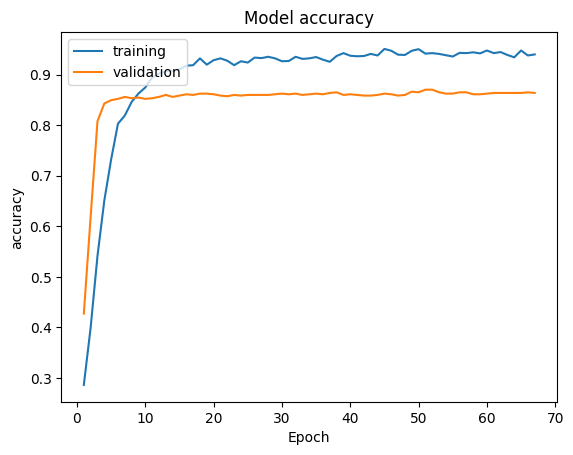

In [38]:
plot_and_save_history(history, checkpoint_dir, metric_name='accuracy')

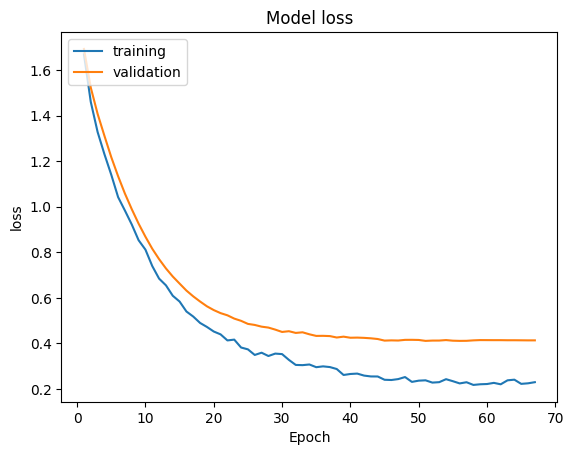

In [39]:
plot_and_save_history(history, checkpoint_dir, metric_name='loss')

In [40]:
train_acc_history = np.asarray(history.history["accuracy"])
val_acc_history = np.asarray(history.history["val_accuracy"])
val_loss_history = np.asarray(history.history["val_loss"])

best_train_acc_epoch = int(np.argmax(train_acc_history)) + 1
best_val_acc_epoch = int(np.argmax(val_acc_history)) + 1
best_val_loss_epoch = int(np.argmin(val_loss_history)) + 1

print(f"Maximum training accuracy:   {train_acc_history[best_train_acc_epoch - 1]:.4f} at epoch {best_train_acc_epoch}")
print(f"Maximum validation accuracy: {val_acc_history[best_val_acc_epoch - 1]:.4f} at epoch {best_val_acc_epoch}")
print(f"Minimum validation loss:     {val_loss_history[best_val_loss_epoch - 1]:.4f} at epoch {best_val_loss_epoch}")

Maximum training accuracy:   0.9507 at epoch 45
Maximum validation accuracy: 0.8701 at epoch 51
Minimum validation loss:     0.4112 at epoch 51


## Evaluate Selected Model

Reload the checkpoint with the highest validation accuracy.

During model optimization, only training and validation results should be inspected. The test set is evaluated only once after the final architecture and hyperparameters have been selected.

In [41]:
best_model = load_model(best_model_path, compile=False)


### Evaluation Utilities

In [42]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


CLASS_NAMES = list(emotion_to_id.keys())
CLASS_IDS = list(range(NUM_CLASSES))


def evaluate_model(model, dataset):
    probabilities = model.predict(dataset, verbose=1)
    y_pred = np.argmax(probabilities, axis=1)
    y_true = np.concatenate([labels.numpy() for _, labels in dataset])

    accuracy = accuracy_score(y_true, y_pred)
    report = classification_report(
        y_true,
        y_pred,
        labels=CLASS_IDS,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )

    return y_true, y_pred, probabilities, accuracy, report

In [43]:
import seaborn as sns


def plot_confusion_matrix(y_true, y_pred, normalize=False, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=CLASS_IDS)

    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        fmt = ".2f"
    else:
        fmt = "d"

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cm, annot=True, cmap='Blues', fmt=fmt, xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("True Class")
    fig.tight_layout()

    return cm, fig

### Training and Validation Results

The training-set evaluation is used only as a diagnostic for overfitting. Validation performance is the basis for comparing candidate model configurations.

In [44]:
# train_eval_ds = create_combined_dataset(
#     train_fea_sequences,
#     train_img_sequences,
#     train_labels,
#     training=False,
#     batch_size=BATCH_SIZE
# )

# train_y_true, train_y_pred, train_probabilities, train_acc, train_report = evaluate_model(best_model, train_eval_ds)

# print(f"Training accuracy: {train_acc:.4%}\n")
# print(train_report)

#### Validation

In [45]:
val_y_true, val_y_pred, val_probabilities, val_acc, val_report = evaluate_model(best_model, val_ds)

print(f"Validation accuracy: {val_acc:.4%}\n")
print(val_report)


25/25 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step  
Validation accuracy: 87.0130%

              precision    recall  f1-score   support

       Anger     0.8925    0.7545    0.8177       110
     Disgust     0.7281    0.7545    0.7411       110
        Fear     0.8529    0.7909    0.8208       110
   Happiness     0.9068    0.9727    0.9386       110
     Neutral     0.9649    1.0000    0.9821       110
     Sadness     0.8211    0.9182    0.8670       110
    Surprise     0.9340    0.9000    0.9167       110

    accuracy                         0.8701       770
   macro avg     0.8715    0.8701    0.8691       770
weighted avg     0.8715    0.8701    0.8691       770



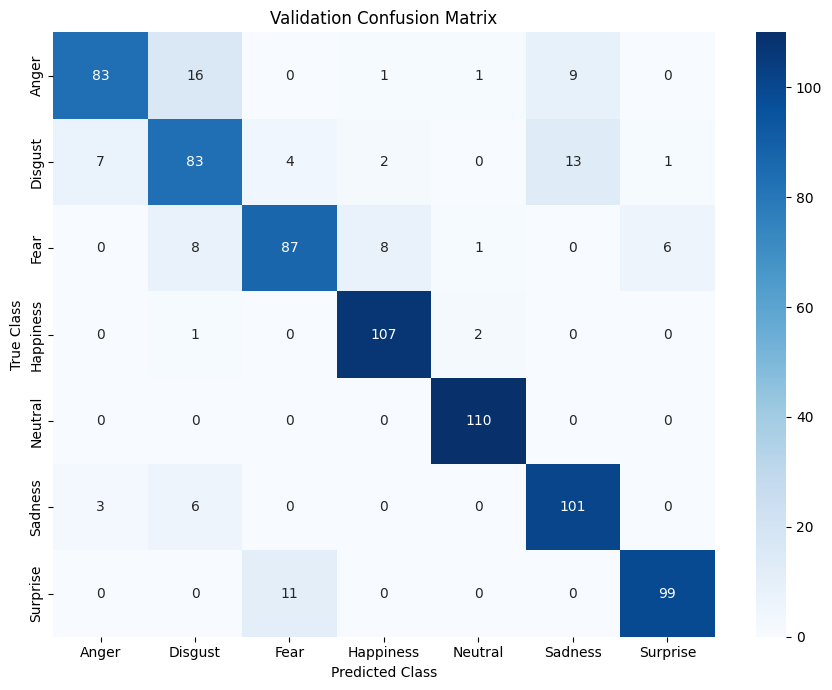

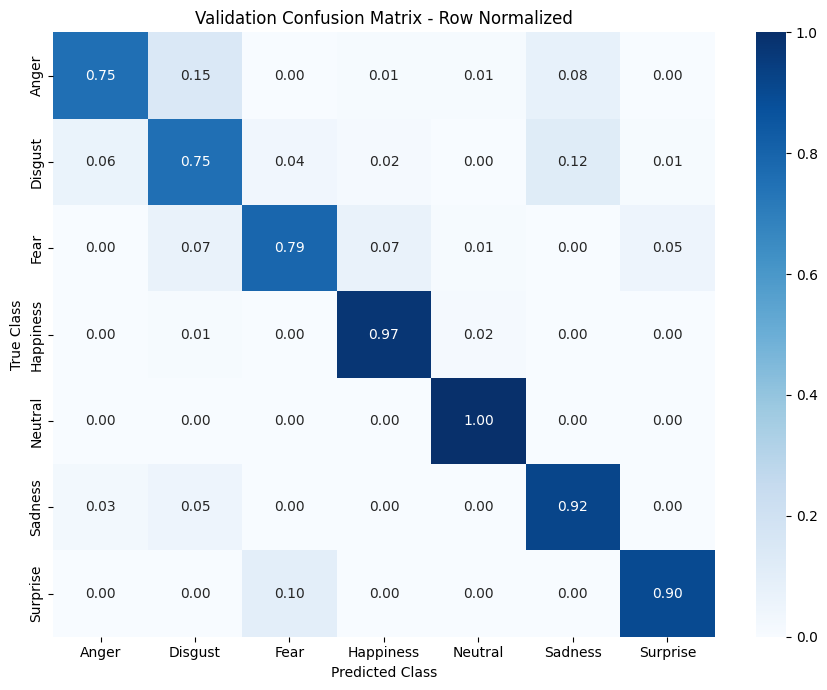

In [46]:
val_cm, val_cm_figure = plot_confusion_matrix(
    val_y_true,
    val_y_pred,
    normalize=False,
    title="Validation Confusion Matrix"
)

val_cm_normalized, val_cm_normalized_figure = plot_confusion_matrix(
    val_y_true,
    val_y_pred,
    normalize=True,
    title="Validation Confusion Matrix - Row Normalized"
)

plt.show()

## Final Test Evaluation

The following cells were only after the architecture and hyperparameters has been selected based on validation performance.

The test set must not be used to choose between candidate configurations.

In [47]:
RUN_FINAL_TEST = True

In [48]:
if not RUN_FINAL_TEST:
    print("Final test evaluation skipped. Set RUN_FINAL_TEST = True only after model selection is complete.")
else:
    test_y_true, test_y_pred, test_probabilities, test_acc, test_report = evaluate_model(best_model, test_ds)

    print(f"Test accuracy: {test_acc:.4%}\n")
    print(test_report)

24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 267ms/step
Test accuracy: 81.6138%

              precision    recall  f1-score   support

       Anger     0.8696    0.5556    0.6780       108
     Disgust     0.5669    0.6667    0.6128       108
        Fear     0.7788    0.8148    0.7964       108
   Happiness     0.7606    1.0000    0.8640       108
     Neutral     0.9444    0.9444    0.9444       108
     Sadness     0.9524    0.9259    0.9390       108
    Surprise     0.9457    0.8056    0.8700       108

    accuracy                         0.8161       756
   macro avg     0.8312    0.8161    0.8149       756
weighted avg     0.8312    0.8161    0.8149       756



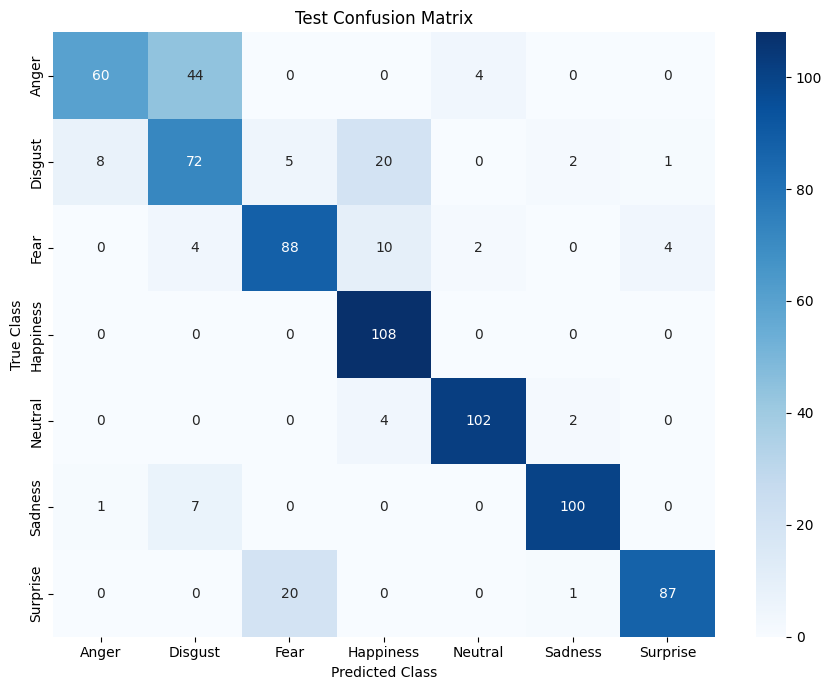

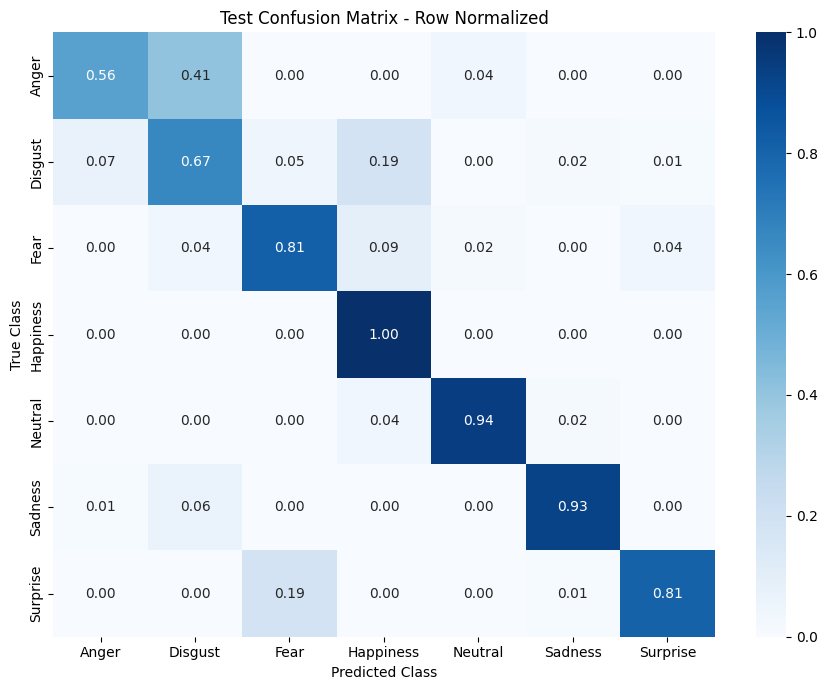

In [49]:
if RUN_FINAL_TEST:
    test_cm, test_cm_figure = plot_confusion_matrix(
        test_y_true,
        test_y_pred,
        normalize=False,
        title="Test Confusion Matrix"
    )

    test_cm_normalized, test_cm_normalized_figure = plot_confusion_matrix(
        test_y_true,
        test_y_pred,
        normalize=True,
        title="Test Confusion Matrix - Row Normalized"
    )

    plt.show()

## Save Experiment Results

Save the model configuration, training history, validation results, and, for the final selected model only, the test predictions and test metrics.

The experiment directory keeps a stable name so that saved paths do not change during execution.

In [51]:
def save_evaluation_results(report, cm_figure, checkpoint_dir):
    with (checkpoint_dir / 'classification_report.txt').open(mode='w') as f:
        f.write(report)
    cm_figure.savefig(str(checkpoint_dir / 'confusion_matrix.png'))

if RUN_FINAL_TEST:
    save_evaluation_results(test_report, test_cm_figure, checkpoint_dir)
else:
    save_evaluation_results(val_report, val_cm_figure, checkpoint_dir)

In [52]:
import time

time.sleep(3)

In [53]:
def add_accuracies_to_checkpoint_dir_name(checkpoint_dir, val_acc, test_acc=None):
    if test_acc:
        new_name = checkpoint_dir.name + f'_val_{str(val_acc)[2:6]}_test_{str(test_acc)[2:6]}'
    else:
        new_name = checkpoint_dir.name + f'_val_{str(val_acc)[2:6]}'
    
    new_path = checkpoint_dir.parent / new_name
    checkpoint_dir.rename(new_path)
    return new_path


if RUN_FINAL_TEST:
    new_checkpoint_dir = add_accuracies_to_checkpoint_dir_name(checkpoint_dir, val_acc, test_acc)
else:
    new_checkpoint_dir = add_accuracies_to_checkpoint_dir_name(checkpoint_dir, val_acc)

In [54]:
time.sleep(8)

In [55]:
import shutil

shutil.copy2((Path() / name_of_this_notebook), (new_checkpoint_dir / name_of_this_notebook))

PosixPath('20260916-2150-intermediate_fusion_cross_attention-seed-13_val_8701_test_8161/intermediate_fusion_cross_attention.ipynb')